# Reward Criteria in a GridWorld MDP

In a Markov Decision Process, the environment produces **immediate rewards**, but the agent still needs a rule for deciding how a sequence of rewards should be evaluated.

Three common reward criteria are:

1. **Total reward**
2. **Average reward**
3. **Discounted reward**

They answer different questions.

This notebook uses the same 7×7 GridWorld to explain all three criteria, calculate them from trajectories generated by the model, compare their behavior, and show when each criterion is appropriate.

> In some notation, reward is written as \(R(s)\), meaning the reward associated with entering state \(s\). In this GridWorld, reward is attached to the transition, so we use the more general notation \(R(s,a,s')\).

## GridWorld

- Start: `(0, 0)`
- Goal: `(6, 6)`
- Obstacles: `(2, 2)`, `(3, 3)`, `(4, 4)`, `(5, 2)`, `(1, 5)`
- Actions: `Up`, `Down`, `Left`, `Right`
- Normal movement reward: `-1`
- Obstacle attempt: `-5` and remain in the same state
- Goal reward: `+10`
- Boundary attempt: `-1` and remain in the same state

The task is episodic: reaching the goal ends the episode.

## 1. Imports and Reproducibility

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

SEED = 42
np.random.seed(SEED)

## 2. Define the GridWorld

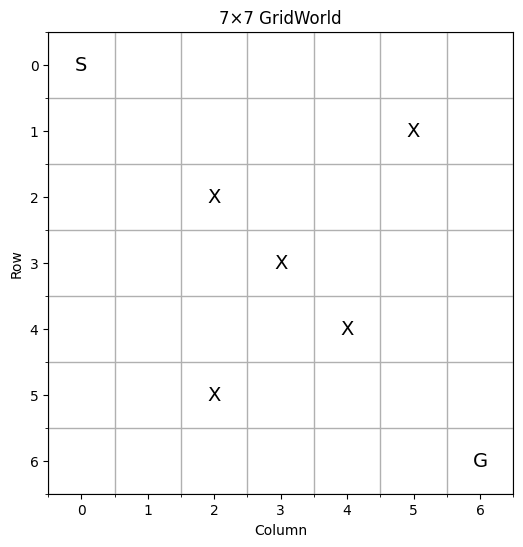

In [ ]:
class GridworldMDP:
    def __init__(self, size=7):
        self.size = size
        self.start_state = (0, 0)
        self.goal_state = (6, 6)
        self.obstacles = {(2, 2), (3, 3), (4, 4), (5, 2), (1, 5)}
        self.action_space = ("Up", "Down", "Left", "Right")
        self.state_space = [(r, c) for r in range(size) for c in range(size) if (r, c) not in self.obstacles]
        self.state = self.start_state

    def reset(self, state=None):
        if state is None:
            state = self.start_state
        if state not in self.state_space:
            raise ValueError("State must be a valid non-obstacle state.")
        self.state = state
        return self.state

    def transition(self, state, action):
        if state == self.goal_state:
            return self.goal_state, 0, True

        row, col = state
        if action == "Up":
            candidate = (max(row - 1, 0), col)
        elif action == "Down":
            candidate = (min(row + 1, self.size - 1), col)
        elif action == "Left":
            candidate = (row, max(col - 1, 0))
        elif action == "Right":
            candidate = (row, min(col + 1, self.size - 1))
        else:
            raise ValueError("Invalid action.")

        if candidate in self.obstacles:
            return state, -5, False
        if candidate == self.goal_state:
            return candidate, 10, True
        return candidate, -1, False

    def step(self, action):
        next_state, reward, done = self.transition(self.state, action)
        self.state = next_state
        return next_state, reward, done

    def plot(self):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(-0.5, self.size - 0.5)
        ax.set_ylim(self.size - 0.5, -0.5)
        ax.set_xticks(range(self.size))
        ax.set_yticks(range(self.size))
        ax.set_xticks(np.arange(-0.5, self.size, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.size, 1), minor=True)
        ax.grid(which="minor", linewidth=1)
        for r in range(self.size):
            for c in range(self.size):
                s = (r, c)
                label = "X" if s in self.obstacles else "S" if s == self.start_state else "G" if s == self.goal_state else ""
                if label:
                    ax.text(c, r, label, ha="center", va="center", fontsize=14)
        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        ax.set_title("7×7 GridWorld")
        plt.show()

env = GridworldMDP()
env.plot()

## 3. Immediate Reward vs. Reward Criterion

The environment supplies one reward after every transition:

$$
R_{t+1}=R(S_t,A_t,S_{t+1})
$$

A **reward criterion** determines how the sequence $R_1,R_2,R_3,\ldots$ is converted into one quantity for comparing behavior.

$$
\text{Total reward}=\sum_t R_t
$$

$$
\text{Average reward}=\lim_{n\to\infty}\frac{1}{n}\sum_{t=1}^{n}R_t
$$

$$
\text{Discounted reward}=\sum_{t=1}^{\infty}\gamma^{t-1}R_t,\qquad 0\leq\gamma<1
$$


## 4. Generate a GridWorld Trajectory

In [ ]:
short_path_actions = ["Down"] * 6 + ["Right"] * 6

def run_episode(env, actions, start_state=None):
    state = env.reset(start_state)
    trajectory = []
    for t, action in enumerate(actions):
        next_state, reward, done = env.step(action)
        trajectory.append({"t": t, "state": state, "action": action, "reward": reward, "next_state": next_state, "done": done})
        state = next_state
        if done:
            break
    return trajectory

short_trajectory = run_episode(env, short_path_actions)
print(f"{'t':<4}{'State':<12}{'Action':<8}{'Reward':<8}{'Next State':<12}{'Done'}")
for row in short_trajectory:
    print(f"{row['t']:<4}{str(row['state']):<12}{row['action']:<8}{row['reward']:<8}{str(row['next_state']):<12}{row['done']}")

t   State       Action  Reward  Next State  Done
0   (0, 0)      Down    -1      (1, 0)      False
1   (1, 0)      Down    -1      (2, 0)      False
2   (2, 0)      Down    -1      (3, 0)      False
3   (3, 0)      Down    -1      (4, 0)      False
4   (4, 0)      Down    -1      (5, 0)      False
5   (5, 0)      Down    -1      (6, 0)      False
6   (6, 0)      Right   -1      (6, 1)      False
7   (6, 1)      Right   -1      (6, 2)      False
8   (6, 2)      Right   -1      (6, 3)      False
9   (6, 3)      Right   -1      (6, 4)      False
10  (6, 4)      Right   -1      (6, 5)      False
11  (6, 5)      Right   10      (6, 6)      True


In [ ]:
short_rewards = [row["reward"] for row in short_trajectory]
print("Reward sequence:", short_rewards)
print("Number of transitions:", len(short_rewards))
print("Final state:", short_trajectory[-1]["next_state"])

Reward sequence: [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 10]
Number of transitions: 12
Final state: (6, 6)


# Part I — Total Reward

## 5. Definition

For a finite episode,

$$
G_{\text{total}}=\sum_{t=1}^{T}R_t.
$$

Every reward contributes its full amount regardless of when it occurs.

In [ ]:
def total_reward(rewards):
    return sum(rewards)

G_total = total_reward(short_rewards)
print("Rewards:", short_rewards)
print("Total reward:", G_total)

Rewards: [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 10]
Total reward: -1


## 6. What Total Reward Encourages

Because every normal movement costs `-1`, a shorter successful route should obtain a larger total reward than a longer successful route.

In [ ]:
long_path_actions = ["Down"] * 6 + ["Right", "Left"] * 3 + ["Right"] * 6
long_trajectory = run_episode(env, long_path_actions)
long_rewards = [row["reward"] for row in long_trajectory]

print("Short route: steps =", len(short_rewards), ", total reward =", total_reward(short_rewards))
print("Long route : steps =", len(long_rewards), ", total reward =", total_reward(long_rewards))
print("Long-route final state:", long_trajectory[-1]["next_state"])

Short route: steps = 12 , total reward = -1
Long route : steps = 18 , total reward = -7
Long-route final state: (6, 6)


### When total reward is useful

Use total reward when:

- the task is **episodic**,
- an episode has a clear end,
- the total reward is finite,
- there is no need to additionally discount later rewards.

For the original goal-reaching GridWorld, total reward is a natural criterion because the episode terminates and the step penalty already encourages efficient paths.

### Limitation

For a continuing task, the infinite sum

$$
R_1+R_2+R_3+\cdots
$$

may diverge. In that case, total reward is not a useful long-run comparison criterion.

# Part II — Average Reward

## 7. Definition

For a continuing process, long-run average reward is

$$
\rho=\lim_{n\to\infty}\frac{1}{n}\sum_{t=1}^{n}R_t.
$$

It measures reward **per time step** rather than accumulated reward.

## 8. Why Long-Run Average Reward Is Not the Main Criterion for One Finite Episode

If this GridWorld episode ends at time $T$, and rewards after termination are treated as zero, then

$$
\frac{R_1+\cdots+R_T+0+0+\cdots}{n}\rightarrow 0
$$

as $n\rightarrow\infty$.

So the long-run average reward of a single terminated episode becomes zero.

A finite **episode-average reward**

$$
\frac{1}{T}\sum_{t=1}^{T}R_t
$$

can still be reported descriptively, but it is not the same as the standard continuing-task average-reward objective.


In [ ]:
episode_average = np.mean(short_rewards)
print("Episode total reward:", total_reward(short_rewards))
print("Episode length:", len(short_rewards))
print("Finite episode-average reward:", episode_average)

Episode total reward: -1
Episode length: 12
Finite episode-average reward: -0.08333333333333333


## 9. Continuing Version of the Same GridWorld

Average reward becomes meaningful if operation continues indefinitely.

For this demonstration, reaching the goal still gives `+10`, but the agent is immediately returned to `(0, 0)` and begins another trip. The grid, obstacles, actions, and immediate reward values remain unchanged.

In [ ]:
def continuing_gridworld_rewards(env, cycle_actions, n_steps):
    env.reset()
    rewards = []
    action_index = 0
    for _ in range(n_steps):
        action = cycle_actions[action_index]
        _, reward, done = env.step(action)
        rewards.append(reward)
        if done:
            env.reset()
            action_index = 0
        else:
            action_index = (action_index + 1) % len(cycle_actions)
    return rewards

continuing_rewards = continuing_gridworld_rewards(env, short_path_actions, 5000)
cumulative_total = np.cumsum(continuing_rewards)
running_average = cumulative_total / np.arange(1, len(continuing_rewards) + 1)

for n in [100, 1000, 5000]:
    print(f"After {n:>4} steps: total={cumulative_total[n-1]:>7.1f}, average={running_average[n-1]:.6f}")

After  100 steps: total=  -12.0, average=-0.120000
After 1000 steps: total=  -87.0, average=-0.087000
After 5000 steps: total= -424.0, average=-0.084800


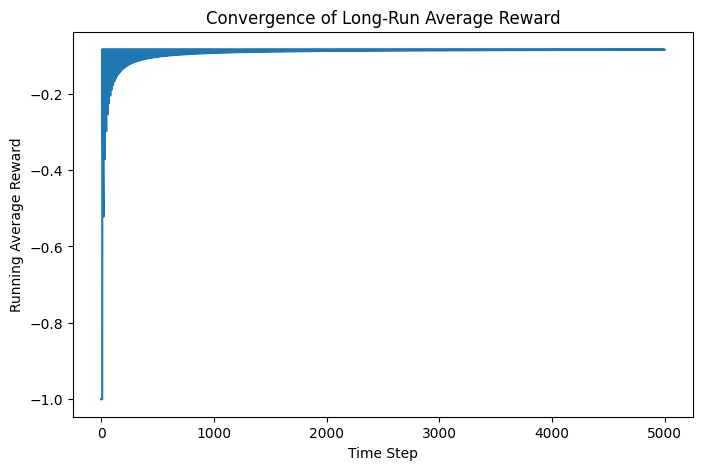

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(running_average)
plt.xlabel("Time Step")
plt.ylabel("Running Average Reward")
plt.title("Convergence of Long-Run Average Reward")
plt.show()

### When average reward is useful

Use average reward when:

- the task is **continuing**,
- there is no natural terminal episode,
- steady long-run performance matters,
- reward per unit time is meaningful.

Examples include continuous manufacturing, long-running material handling, server allocation, traffic control, inventory control, and dispatching systems.

### Limitation

Average reward does not explicitly prefer an earlier reward over a later one if both policies have the same long-run reward rate.

# Part III — Discounted Reward

## 10. Definition

The discounted return is

$$
G_t=R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots
$$

or

$$
G_t=\sum_{k=0}^{\infty}\gamma^kR_{t+k+1},\qquad 0\leq\gamma<1.
$$

Later rewards receive smaller weights.

In [ ]:
def discounted_reward(rewards, gamma):
    return sum((gamma ** t) * reward for t, reward in enumerate(rewards))

for gamma in [0.0, 0.5, 0.9, 0.99]:
    print(f"gamma={gamma:<4} discounted reward={discounted_reward(short_rewards, gamma):.6f}")

gamma=0.0  discounted reward=-1.000000
gamma=0.5  discounted reward=-1.994141
gamma=0.9  discounted reward=-3.723788
gamma=0.99 discounted reward=-1.512792


## 11. Effect of the Discount Factor

A reward received $k$ steps in the future is weighted by

$$
\gamma^k
$$

A smaller $\gamma$ places more emphasis on near-term rewards. A larger $\gamma$ gives distant rewards more influence.


In [ ]:
gamma = 0.9
steps = np.arange(0, 21)
weights = gamma ** steps
for step, weight in zip(steps[:10], weights[:10]):
    print(f"{step:>2} steps ahead -> weight = {weight:.6f}")

 0 steps ahead -> weight = 1.000000
 1 steps ahead -> weight = 0.900000
 2 steps ahead -> weight = 0.810000
 3 steps ahead -> weight = 0.729000
 4 steps ahead -> weight = 0.656100
 5 steps ahead -> weight = 0.590490
 6 steps ahead -> weight = 0.531441
 7 steps ahead -> weight = 0.478297
 8 steps ahead -> weight = 0.430467
 9 steps ahead -> weight = 0.387420


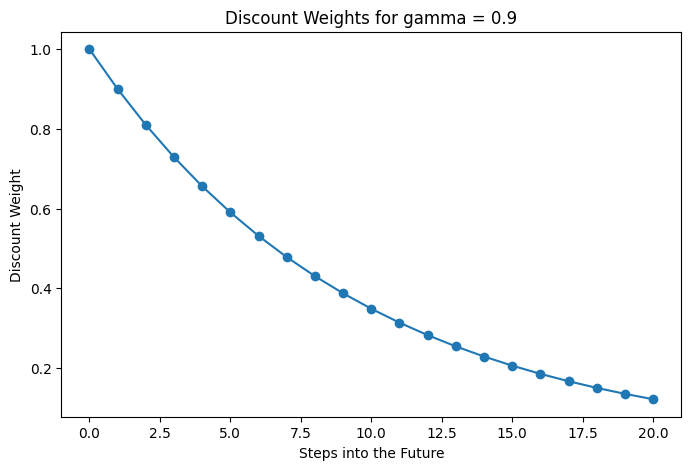

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(steps, weights, marker="o")
plt.xlabel("Steps into the Future")
plt.ylabel("Discount Weight")
plt.title("Discount Weights for gamma = 0.9")
plt.show()

## 12. Earlier vs. Later Goal Reward

The GridWorld can demonstrate why discounting prefers earlier outcomes.

From `(5, 6)`, the goal is one move away. From `(3, 6)`, the goal is three moves away.

In [ ]:
near_goal = run_episode(env, ["Down"], start_state=(5, 6))
farther_from_goal = run_episode(env, ["Down", "Down", "Down"], start_state=(3, 6))

near_rewards = [row["reward"] for row in near_goal]
far_rewards = [row["reward"] for row in farther_from_goal]

gamma = 0.9
print("Near-goal rewards:", near_rewards)
print("Farther-state rewards:", far_rewards)
print("Near-goal discounted reward:", discounted_reward(near_rewards, gamma))
print("Farther-state discounted reward:", discounted_reward(far_rewards, gamma))

Near-goal rewards: [10]
Farther-state rewards: [-1, -1, 10]
Near-goal discounted reward: 10.0
Farther-state discounted reward: 6.200000000000001


## 13. Why Discounting Helps with Infinite Horizons

Suppose a continuing process gives reward `+1` forever.

Total reward is

$$
1+1+1+\cdots
$$

which diverges.

Discounted reward is

$$
1+\gamma+\gamma^2+\cdots
$$

and for $0\leq\gamma<1$,

$$
\sum_{t=0}^{\infty}\gamma^t=\frac{1}{1-\gamma}.
$$

In [ ]:
for gamma in [0.5, 0.9, 0.99]:
    theoretical = 1 / (1 - gamma)
    approximate = sum(gamma ** t for t in range(10000))
    print(f"gamma={gamma}: theoretical={theoretical:.6f}, numerical={approximate:.6f}")

gamma=0.5: theoretical=2.000000, numerical=2.000000
gamma=0.9: theoretical=10.000000, numerical=10.000000
gamma=0.99: theoretical=100.000000, numerical=100.000000


### When discounted reward is useful

Use discounted reward when:

- future rewards should count less than immediate rewards,
- the task can continue indefinitely,
- a finite return is needed,
- earlier success should be preferred,
- long-term consequences still matter but with decreasing weight.

Discounted reward is also common in episodic RL even when total reward is finite.

# Part IV — Compare the Three Criteria on the Same GridWorld

## 14. Short Route vs. Long Route

In [ ]:
def summarize_episode(rewards, gamma=0.9):
    return {
        "steps": len(rewards),
        "total": total_reward(rewards),
        "episode_average": np.mean(rewards),
        "discounted": discounted_reward(rewards, gamma),
    }

short_summary = summarize_episode(short_rewards, 0.9)
long_summary = summarize_episode(long_rewards, 0.9)

print("Metric".ljust(22), "Short Route".rjust(14), "Long Route".rjust(14))
print("-" * 52)
for key, label in [("steps", "Steps"), ("total", "Total reward"), ("episode_average", "Episode average"), ("discounted", "Discounted reward")]:
    print(label.ljust(22), f"{short_summary[key]:>14.6f}", f"{long_summary[key]:>14.6f}")

Metric                    Short Route     Long Route
----------------------------------------------------
Steps                       12.000000      18.000000
Total reward                -1.000000      -7.000000
Episode average             -0.083333      -0.388889
Discounted reward           -3.723788      -6.664564


## 15. Practical Selection Guide

| Situation | Recommended criterion | Reason |
|---|---|---|
| Finite episode with a clear end | **Total reward** | The reward sum is finite and directly measures episode performance |
| Finite episode where reward timing matters | **Discounted reward** | Earlier rewards receive greater weight |
| Infinite or very long continuing operation | **Average reward** | Measures stable reward per time step |
| Infinite horizon where a finite return is required | **Discounted reward** | Discounting keeps the return finite when \(\gamma<1\) |
| Long-run operational efficiency | **Average reward** | Directly measures steady-state reward rate |
| Goal-reaching task with step penalties | **Total or discounted reward** | Both favor efficient goal completion |

## 16. Which Criterion Fits This GridWorld?

### Original episodic GridWorld

The episode ends when the goal is reached. A natural choice is **total reward** because the sum is finite and the `-1` step cost already penalizes unnecessary movement.

Discounted reward is also appropriate when reaching the goal sooner should receive additional preference.

### Continuing version

If reaching the goal resets the agent and operation continues indefinitely, **average reward** becomes a natural objective for long-run reward per step.

Discounted reward can also be used for continuing tasks when future rewards should receive progressively less weight.

## 17. Important Terminology

### Reward

One immediate signal:

$$
R_{t+1}
$$

### Total reward

$$
\sum_t R_t
$$

### Average reward

$$
\lim_{n\to\infty}\frac{1}{n}\sum_{t=1}^{n}R_t
$$

### Discounted return

$$
G_t=\sum_{k=0}^{\infty}\gamma^kR_{t+k+1}
$$

### Reward function

The rule used by the environment to assign immediate reward:

\[
R(s,a,s')
\]

The **reward function** defines what immediate reward is produced. The **reward criterion** defines how the sequence of rewards is evaluated.

## 18. Final Summary

### Total reward

$$
\sum_tR_t
$$

Best suited to finite episodic tasks when the reward sum is well defined.

### Average reward

$$
\lim_{n\to\infty}\frac{1}{n}\sum_{t=1}^{n}R_t
$$

Best suited to continuing systems where long-run reward per step matters.

### Discounted reward

$$
\sum_t\gamma^tR_t
$$

Best suited when future rewards should receive less weight or when an infinite-horizon reward sum needs to remain finite.

For the original goal-reaching GridWorld, **total reward or discounted reward** is the natural choice. For a continuing version of the same GridWorld, **average reward** becomes a natural long-run objective.

## Reward Convention

There are two common ways to define rewards in an MDP.

### 1. State-Action Reward: $R(s,a)$

In this convention, the reward depends only on the current state $s$ and the action $a$ selected by the agent.

The interaction can be written as:

$$
S_t \rightarrow A_t \rightarrow R_{t+1} \rightarrow S_{t+1}
$$

The reward is associated with taking action $A_t$ in state $S_t$.

The Bellman optimality equation is

$$
V^*(s)=\max_a\left[R(s,a)+\gamma\sum_{s'}P(s'|s,a)V^*(s')\right]
$$

This form is appropriate when the immediate reward is known once the current state and action are known.

### 2. Transition-Based Reward: $R(s,a,s')$

In this convention, the reward depends on the current state $s$, the selected action $a$, and the next state $s'$ reached after the transition.

The interaction can be written as:

$$
S_t \rightarrow A_t \rightarrow S_{t+1},R_{t+1}
$$

The environment first determines the transition outcome, and the reward is associated with that particular transition.

The Bellman optimality equation is

$$
V^*(s)=\max_a\sum_{s'}P(s'|s,a)\left[R(s,a,s')+\gamma V^*(s')\right]
$$

This form is useful when the same action can lead to different next states with different rewards.

